# How to calculate the spatial gradient of a scalar field in cylindrical coordiantes

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

### Cylindrical coordinates:

FELiCS is able to handle cartesian and cylindrical coordinates. The cylindrical coordinates in FELiCS are defined with (x, r, theta) where x is analogous to the x in cartesian coordinates, r is the radial component (distance from x-axis) and theta is the azimuthal/angular coordinate which is the angle around the x-axis.
with this coordinate choice our square mesh is basically "rolled" into a cylinder.

=> put equation of gradient with derivative w.r.t. spectral dimension (if any doubt, see https://en.wikipedia.org/wiki/Del_in_cylindrical_and_spherical_coordinates)

=> put validation field creation in its own cell and explain shortly (do we need it here?)

=> put a "TODO" note for later (for after the retreat): for the cylindrical coordinates, if there is a boundary with r=0, this axis is a symmetry boundary, thus there HAS to be either a zero Dirichlet or a zero Neumann condition for "a". We don't set any boundary conditions yet (because the Neumann handling will be implemented after the retreat), but here a Neumann condition should be set for both r and theta

In [2]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cylindrical"
m = 3

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import createFunctionSpace

scalarSpace = createFunctionSpace(mesh, order=2, dim=1)
vectorSpace = createFunctionSpace(mesh, order=2, dim=3)

from FELiCS.Fields.Field import Field

phi = Field(scalarSpace, mesh=mesh, m = m)
phi.importH5("function_values_sine")
gradPhiSol = Field(vectorSpace, mesh=mesh)
gradPhiSol.importH5("grad_solution_cylSpectral_m=3")

fatal: not a git repository: '/home/knechtel/miniconda3/envs/felics2025_dolfin9/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


**Step 2: Define the gradient Expression and evaluate it on the Field**

We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field 

In [3]:
##################################
# Tensor Utils stuff in Tensor Utils tutorial
from ufl import TestFunction, dx, conj
from FELiCS.Misc.tensorUtils import iGrad, iConj, iDot, Tensor
import dolfinx.fem

J_hat = mesh.coordinateSystem.J_hat
v = TestFunction(vectorSpace)
v_tens = Tensor(v, CoordSys=mesh.coordinateSystem, hasSpectralDimension=True)
expression = iDot(iGrad(phi.getTensor()), iConj(v_tens)).ufl_tens * J_hat* dx
###################################

gradPhi = phi.getGradientField()

print(sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

(-0.19815778792017957+92.17994219902604j)


**Step 3: Postprocessing**

Visualization of the gradients with 

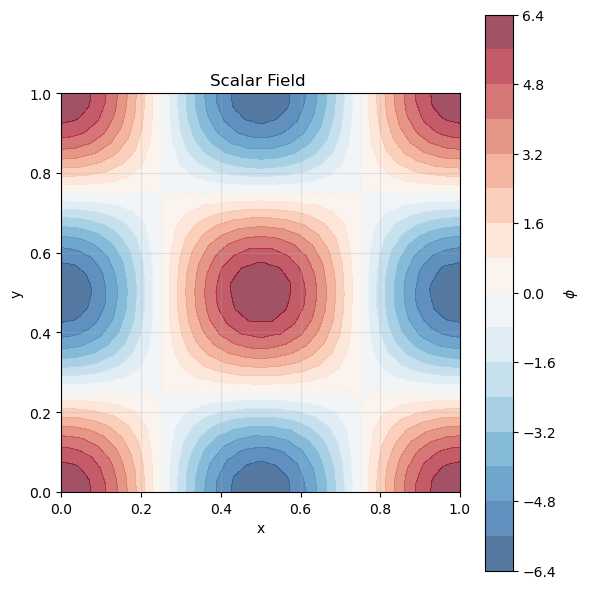

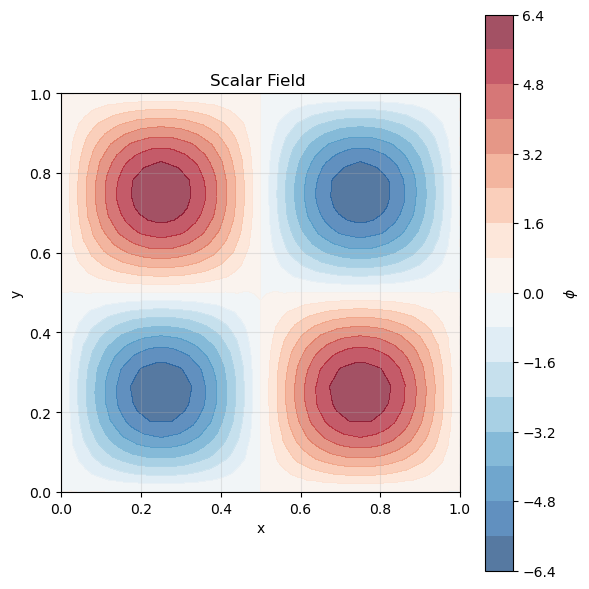

In [4]:
gradPhiList = gradPhi.getListOfSingleFields()
phi_x = gradPhiList[0]
phi_r = gradPhiList[1]
phi_x.plot()
phi_r.plot()